In [215]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib


In [216]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df  = pd.read_csv("../data/processed/test.csv")

print("Train+Val shape:", train_df.shape)
print("Test shape     :", test_df.shape)


Train+Val shape: (2924, 12)
Test shape     : (731, 12)


In [217]:
split_idx = int(len(train_df) * 0.8)

train_part = train_df.iloc[:split_idx]
val_part   = train_df.iloc[split_idx:]


In [218]:
X_train = train_part.drop(columns=["daily_demand_qty"])
y_train = train_part["daily_demand_qty"]

X_val = val_part.drop(columns=["daily_demand_qty"])
y_val = val_part["daily_demand_qty"]

X_test = test_df.drop(columns=["daily_demand_qty"])
y_test = test_df["daily_demand_qty"]


In [219]:
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=4,
    min_samples_split=7,
    random_state=42,
    n_jobs=-1
)


In [220]:
model.fit(X_train, y_train)


RandomForestRegressor(max_depth=4, min_samples_split=7, n_estimators=150,
                      n_jobs=-1, random_state=42)

In [221]:
train_pred = model.predict(X_train)
val_pred   = model.predict(X_val)
test_pred  = model.predict(X_test)


In [222]:
def evaluate_set(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"{name} SET:")
    print(f"R² Score: {r2:.4f} ({r2*100:.2f}% variance explained)")
    print(f"RMSE   : {rmse:.3f} units/day")
    print(f"MAE    : {mae:.3f} units/day")
    print("-" * 50)


In [223]:
evaluate_set("TRAINING", y_train, train_pred)
evaluate_set("VALIDATION", y_val, val_pred)
evaluate_set("TEST", y_test, test_pred)


TRAINING SET:
R² Score: 0.8866 (88.66% variance explained)
RMSE   : 11.437 units/day
MAE    : 9.373 units/day
--------------------------------------------------
VALIDATION SET:
R² Score: 0.8370 (83.70% variance explained)
RMSE   : 14.805 units/day
MAE    : 10.284 units/day
--------------------------------------------------
TEST SET:
R² Score: 0.8893 (88.93% variance explained)
RMSE   : 11.310 units/day
MAE    : 9.401 units/day
--------------------------------------------------


In [224]:
baseline_pred = np.full_like(y_test, y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mape = np.mean(np.abs((y_test - baseline_pred) / y_test)) * 100

print("BASELINE MODEL:")
print("MAE  :", round(baseline_mae, 2))
print("MAPE :", round(baseline_mape, 2), "%")


BASELINE MODEL:
MAE  : 28.45
MAPE : 25.65 %


In [225]:
joblib.dump(model, "../models/random_forest_model.pkl")
print("✅ Model saved to models/random_forest_model.pkl")


✅ Model saved to models/random_forest_model.pkl


In [226]:
import sys
import os
import joblib

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from rules.rule_engine import apply_rules

# Load trained model
model = joblib.load("../models/random_forest_model.pkl")

# Example sample
sample = X_test.iloc[0:1]
ml_prediction = model.predict(sample)[0]

final_prediction = apply_rules(
    base_prediction=ml_prediction,
    is_festival=1,
    festival_type="Sinhala_Tamil_New_Year",
    is_poya_day=0,
    is_heavy_rain=0,
    is_weekend=1
)

print("ML Prediction    :", round(ml_prediction, 2))
print("Final Prediction :", final_prediction)


ML Prediction    : 117.43
Final Prediction : 253.66


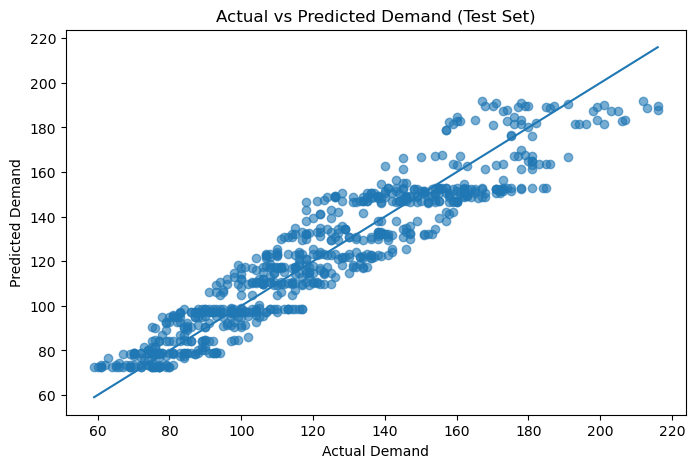

In [227]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand (Test Set)")
plt.show()


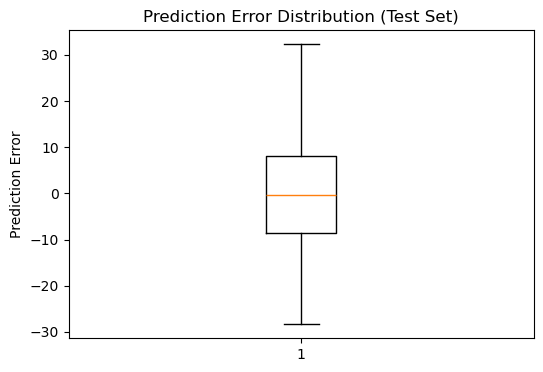

In [228]:
errors = y_test - test_pred

plt.figure(figsize=(6,4))
plt.boxplot(errors, vert=True)
plt.ylabel("Prediction Error")
plt.title("Prediction Error Distribution (Test Set)")
plt.show()


In [229]:
import numpy as np

Q1 = np.percentile(errors, 25)
Q3 = np.percentile(errors, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = errors[(errors < lower_bound) | (errors > upper_bound)]

print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of outliers:", len(outliers))


Lower bound: -33.6
Upper bound: 33.16
Number of outliers: 0
